In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import copy
import glob
import warnings

import healpy
import fitsio

import numpy as np 

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.table import Table, Column, vstack

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

warnings.filterwarnings('ignore', category=UserWarning, append=True)

In [2]:
from unagi import hsc
from unagi import task
from unagi import query
from unagi import config
from unagi import catalog
from unagi import plotting

s20a_w = hsc.Hsc(dr='dr3', rerun='s20a_wide')

# Get table list from /Users/song/Dropbox/work/project/unagi/unagi/data/s20a_wide/s20a_wide_tables.fits


In [3]:
def filter_healpix_mask(mask, catalog, ra='ra', dec='dec', verbose=True):
    """Filter a catalog through a Healpix mask.
    Parameters
    ----------
    mask : healpy mask data
        healpy mask data
    catalog : numpy array or astropy.table
        Catalog that includes the coordinate information
    ra : string
        Name of the column for R.A.
    dec : string
        Name of the column for Dec.
    verbose : boolen, optional
        Default: True
    Return
    ------
        Selected objects that are covered by the mask.
    """
    import healpy

    nside, hp_indices = healpy.get_nside(mask), np.where(mask)[0]

    phi, theta = np.radians(catalog[ra]), np.radians(90. - catalog[dec])

    hp_masked = healpy.ang2pix(nside, theta, phi, nest=True)

    select = np.in1d(hp_masked, hp_indices)

    if verbose:
        print("# %d/%d objects are selected by the mask" % (select.sum(), len(catalog)))

    return catalog[select]

### Gaia EDR3 catalogs in the general HSC survey area

In [11]:
gaia_dir = '/Users/song/Downloads/gaia_edr3_hsc/'

gaia_cat_list = glob.glob(gaia_dir + '*.fits.gz')

In [12]:
gaia_cat_list

['/Users/song/Downloads/gaia_edr3_hsc/hsc_autumn_1-result.fits.gz',
 '/Users/song/Downloads/gaia_edr3_hsc/hsc_autumn_2-result.fits.gz',
 '/Users/song/Downloads/gaia_edr3_hsc/hsc_hectomap-result.fits.gz',
 '/Users/song/Downloads/gaia_edr3_hsc/hsc_spring-result.fits.gz',
 '/Users/song/Downloads/gaia_edr3_hsc/hsc_elais_n1-result.fits.gz']

### HSC S20A FDFC mask

- An initial one

In [13]:
s20a_fdfc = healpy.read_map(os.path.join(gaia_dir, 's20a_fdfc_hp_contarea_izy-gt-5.fits'), nest=True, dtype=np.bool)

# 543480/1482258 objects are selected by the mask


Text(0, 0.5, '$\\rm Dec\\ [deg]$')

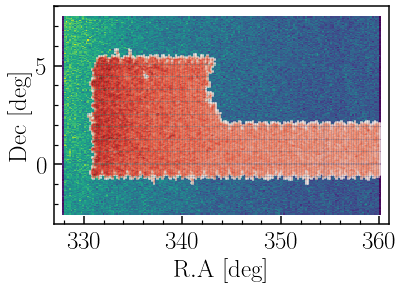

In [33]:
hsc_1 = fitsio.read(gaia_cat_list[0])
hsc_1_filt = filter_healpix_mask(
    s20a_fdfc, hsc_1, ra='ra', dec='dec', verbose=True)

_ = plt.hist2d(hsc_1['ra'], hsc_1['dec'], bins=(200, 200), range=([327, 361], [-3, 8]), cmin=1)

_ = plt.hist2d(hsc_1_filt['ra'], hsc_1_filt['dec'], bins=(200, 200), range=([327, 361], [-3, 8]), 
               alpha=0.5, cmap='Reds', cmin=1)

plt.xlabel(r'$\rm R.A\ [deg]$', fontsize=25)
plt.ylabel(r'$\rm Dec\ [deg]$', fontsize=25)

# 249389/1629452 objects are selected by the mask


Text(0, 0.5, '$\\rm Dec\\ [deg]$')

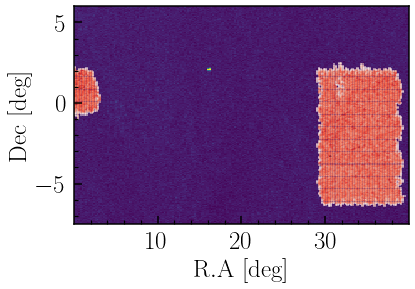

In [36]:
hsc_2 = fitsio.read(gaia_cat_list[1])
hsc_2_filt = filter_healpix_mask(
    s20a_fdfc, hsc_2, ra='ra', dec='dec', verbose=True)

_ = plt.hist2d(
    hsc_2['ra'], hsc_2['dec'], bins=(200, 200), 
    range=([np.min(hsc_2['ra']), np.max(hsc_2['ra'])], [np.min(hsc_2['dec']), np.max(hsc_2['dec'])]))

_ = plt.hist2d(
    hsc_2_filt['ra'], hsc_2_filt['dec'], bins=(200, 200), 
    range=([np.min(hsc_2['ra']), np.max(hsc_2['ra'])], [np.min(hsc_2['dec']), np.max(hsc_2['dec'])]),
    alpha=0.5, cmap='Reds', cmin=1)

plt.xlabel(r'$\rm R.A\ [deg]$', fontsize=25)
plt.ylabel(r'$\rm Dec\ [deg]$', fontsize=25)

# 228020/644954 objects are selected by the mask


Text(0, 0.5, '$\\rm Dec\\ [deg]$')

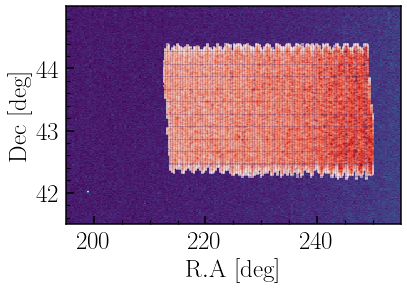

In [37]:
hsc_3 = fitsio.read(gaia_cat_list[2])
hsc_3_filt = filter_healpix_mask(
    s20a_fdfc, hsc_3, ra='ra', dec='dec', verbose=True)

_ = plt.hist2d(
    hsc_3['ra'], hsc_3['dec'], bins=(200, 200), 
    range=([np.min(hsc_3['ra']), np.max(hsc_3['ra'])], [np.min(hsc_3['dec']), np.max(hsc_3['dec'])]))

_ = plt.hist2d(
    hsc_3_filt['ra'], hsc_3_filt['dec'], bins=(200, 200), 
    range=([np.min(hsc_3['ra']), np.max(hsc_3['ra'])], [np.min(hsc_3['dec']), np.max(hsc_3['dec'])]),
    alpha=0.5, cmap='Reds', cmin=1)

plt.xlabel(r'$\rm R.A\ [deg]$', fontsize=25)
plt.ylabel(r'$\rm Dec\ [deg]$', fontsize=25)

# 1656525/3988051 objects are selected by the mask


Text(0, 0.5, '$\\rm Dec\\ [deg]$')

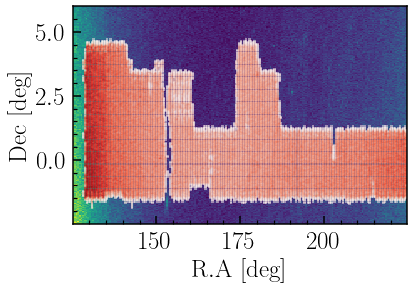

In [39]:
hsc_4 = fitsio.read(gaia_cat_list[3])
hsc_4_filt = filter_healpix_mask(
    s20a_fdfc, hsc_4, ra='ra', dec='dec', verbose=True)

_ = plt.hist2d(
    hsc_4['ra'], hsc_4['dec'], bins=(200, 200), 
    range=([np.min(hsc_4['ra']), np.max(hsc_4['ra'])], [np.min(hsc_4['dec']), np.max(hsc_4['dec'])]))

_ = plt.hist2d(
    hsc_4_filt['ra'], hsc_4_filt['dec'], bins=(200, 200), 
    range=([np.min(hsc_4['ra']), np.max(hsc_4['ra'])], [np.min(hsc_4['dec']), np.max(hsc_4['dec'])]),
    alpha=0.5, cmap='Reds', cmin=1)

plt.xlabel(r'$\rm R.A\ [deg]$', fontsize=25)
plt.ylabel(r'$\rm Dec\ [deg]$', fontsize=25)

In [43]:
s20a_edr3 = vstack([
    Table(hsc_1_filt), Table(hsc_2_filt), Table(hsc_3_filt), Table(hsc_4_filt)])

print(len(s20a_edr3))

2677414


In [44]:
s20a_edr3.write(os.path.join(gaia_dir, 'gaia_edr3_hsc_s20a_fdfc.fits'), overwrite=True)

## Explore the selection of extended objects in different parameter spaces

In [4]:
gaia_dir = '/Users/song/Downloads/gaia_edr3_hsc/'
s20a_edr3 = Table.read(os.path.join(gaia_dir, 'gaia_edr3_hsc_s20a_fdfc.fits'))

### Very rough selection of "galaxies"

In [5]:
mask = (
    np.isfinite(s20a_edr3['phot_g_mean_mag']) &
    np.isfinite(s20a_edr3['phot_bp_rp_excess_factor']) &
    np.isfinite(s20a_edr3['ruwe']) &
    np.isfinite(s20a_edr3['astrometric_excess_noise']) &
    np.isfinite(s20a_edr3['scan_direction_strength_k1']) & 
    np.isfinite(s20a_edr3['scan_direction_strength_k2']) &
    np.isfinite(s20a_edr3['scan_direction_strength_k3']) &
    np.isfinite(s20a_edr3['scan_direction_strength_k4']) &
    np.isfinite(s20a_edr3['scan_direction_mean_k1']) & 
    np.isfinite(s20a_edr3['scan_direction_mean_k2']) &
    np.isfinite(s20a_edr3['scan_direction_mean_k3']) &
    np.isfinite(s20a_edr3['scan_direction_mean_k4']) & 
    (~s20a_edr3['duplicated_source']) &
    (s20a_edr3['parallax_over_error'] <= 40) & 
    (np.abs(s20a_edr3['pmra'] / s20a_edr3['pmra_error']) <= 100) &
    (np.abs(s20a_edr3['pmdec'] / s20a_edr3['pmdec_error']) <= 100)
)

print(mask.sum() / len(s20a_edr3))

hsc_use = s20a_edr3[mask]

0.6170637040069261


Text(0, 0.5, '${\\tt astrometric\\_excess\\_noise}$')

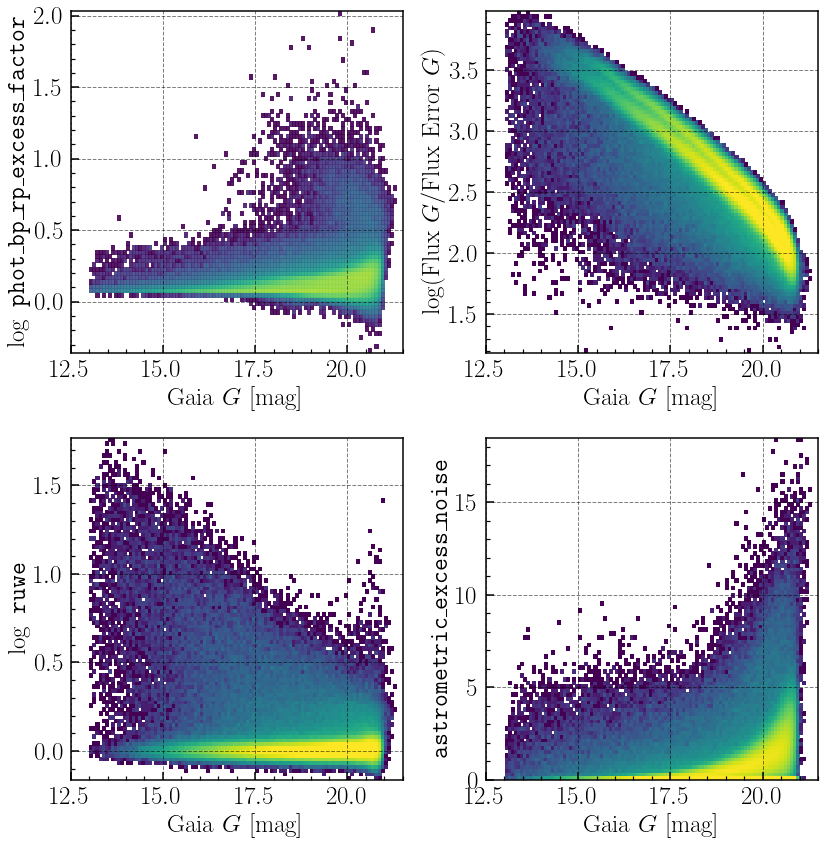

In [6]:
fig = plt.figure(figsize=(12, 12))
plt.subplots_adjust(bottom=0.1, right=0.99, top=0.99, hspace=0.25, wspace=0.25)

# Magnitude v.s. photometric excess factor
ax1 = fig.add_subplot(221)

_ = ax1.hist2d(hsc_use['phot_g_mean_mag'], np.log10(hsc_use['phot_bp_rp_excess_factor']), bins=(100, 80), 
               vmin=1, norm=LogNorm(vmin=1, vmax=50000), alpha=0.9)

#plt.scatter(resolved['phot_g_mean_mag'], np.log10(resolved['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='salmon')

ax1.grid(linestyle='--', c='k', alpha=0.5)

ax1.set_xlim(12.5, 21.5)

ax1.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax1.set_ylabel(r'$\log\ {\tt phot\_bp\_rp\_excess\_factor} $', fontsize=25)


# Magnitude v.s. Flux-over-error
ax2 = fig.add_subplot(222)

_ = ax2.hist2d(hsc_use['phot_g_mean_mag'], np.log10(hsc_use['phot_g_mean_flux_over_error']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000))

ax2.grid(linestyle='--', c='k', alpha=0.5)

ax2.set_xlim(12.5, 21.5)

ax2.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax2.set_ylabel(r'$\log({\rm Flux}\ G / {\rm Flux\ Error}\ G)$', fontsize=25)

# ruwe parameter
ax3 = fig.add_subplot(223)

_ = ax3.hist2d(hsc_use['phot_g_mean_mag'], np.log10(hsc_use['ruwe']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000))

ax3.grid(linestyle='--', c='k', alpha=0.5)

ax3.set_xlim(12.5, 21.5)

ax3.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax3.set_ylabel(r'$\log\ {\tt ruwe}$', fontsize=25)


ax4 = fig.add_subplot(224)

_ = ax4.hist2d(hsc_use['phot_g_mean_mag'], hsc_use['astrometric_excess_noise'], bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000))

ax4.grid(linestyle='--', c='k', alpha=0.5)

ax4.set_xlim(12.5, 21.5)

ax4.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax4.set_ylabel(r'${\tt astrometric\_excess\_noise}$', fontsize=25)

Text(0, 0.5, '${\\tt astrometric\\_excess\\_noise}$')

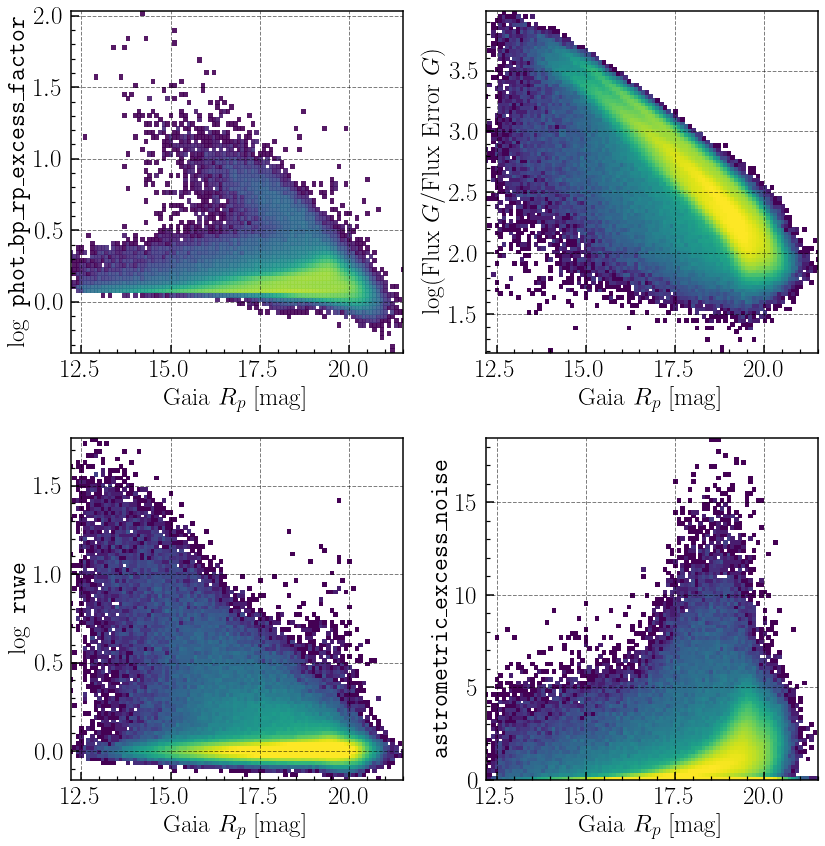

In [7]:
fig = plt.figure(figsize=(12, 12))
plt.subplots_adjust(bottom=0.1, right=0.99, top=0.99, hspace=0.25, wspace=0.25)

# Magnitude v.s. photometric excess factor
ax1 = fig.add_subplot(221)

_ = ax1.hist2d(hsc_use['phot_rp_mean_mag'], np.log10(hsc_use['phot_bp_rp_excess_factor']), bins=(100, 80), 
               vmin=1, norm=LogNorm(vmin=1, vmax=50000), alpha=0.9)

#plt.scatter(resolved['phot_g_mean_mag'], np.log10(resolved['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='salmon')

ax1.grid(linestyle='--', c='k', alpha=0.5)

ax1.set_xlim(12.2, 21.5)

ax1.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax1.set_ylabel(r'$\log\ {\tt phot\_bp\_rp\_excess\_factor} $', fontsize=25)


# Magnitude v.s. Flux-over-error
ax2 = fig.add_subplot(222)

_ = ax2.hist2d(hsc_use['phot_rp_mean_mag'], np.log10(hsc_use['phot_g_mean_flux_over_error']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000))

ax2.grid(linestyle='--', c='k', alpha=0.5)

ax2.set_xlim(12.2, 21.5)

ax2.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax2.set_ylabel(r'$\log({\rm Flux}\ G / {\rm Flux\ Error}\ G)$', fontsize=25)

# ruwe parameter
ax3 = fig.add_subplot(223)

_ = ax3.hist2d(hsc_use['phot_rp_mean_mag'], np.log10(hsc_use['ruwe']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000))

ax3.grid(linestyle='--', c='k', alpha=0.5)

ax3.set_xlim(12.2, 21.5)

ax3.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax3.set_ylabel(r'$\log\ {\tt ruwe}$', fontsize=25)


ax4 = fig.add_subplot(224)

_ = ax4.hist2d(hsc_use['phot_rp_mean_mag'], hsc_use['astrometric_excess_noise'], bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000))

ax4.grid(linestyle='--', c='k', alpha=0.5)

ax4.set_xlim(12.2, 21.5)

ax4.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax4.set_ylabel(r'${\tt astrometric\_excess\_noise}$', fontsize=25)

#### Make a few selection based on `rp` magnitude

In [8]:
flag_1 = (
    (hsc_use['phot_rp_mean_mag'] >= 15.0) & (hsc_use['phot_rp_mean_mag'] < 17.0) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) >= 0.5) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) <= 1.5) & 
    (np.log10(hsc_use['ruwe']) >= 0.09)
)

print(flag_1.sum())

resolved_1 = hsc_use[flag_1]

838


In [9]:
flag_2 = (
    (hsc_use['phot_rp_mean_mag'] >= 17.0) & (hsc_use['phot_rp_mean_mag'] < 18.5) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) >= 0.5) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) <= 1.5) & 
    (np.log10(hsc_use['ruwe']) >= 0.09)
)

print(flag_2.sum())

resolved_2 = hsc_use[flag_2]

2997


In [10]:
flag_3 = (
    (hsc_use['phot_rp_mean_mag'] >= 18.5) & (hsc_use['phot_rp_mean_mag'] < 20.0) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) >= 0.3) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) <= 1.5) & 
    (np.log10(hsc_use['ruwe']) >= 0.09)
)

print(flag_3.sum())

resolved_3 = hsc_use[flag_3]

3067


In [11]:
flag_4 = (
    (hsc_use['phot_rp_mean_mag'] >= 17.0) & (hsc_use['phot_rp_mean_mag'] < 18.5) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) >= 0.3) &
    (np.log10(hsc_use['phot_bp_rp_excess_factor']) < 0.5) & 
    (np.log10(hsc_use['ruwe']) >= 0.09)
)

print(flag_4.sum())

resolved_4 = hsc_use[flag_4]

1955


Text(0, 0.5, '${\\tt astrometric\\_excess\\_noise}$')

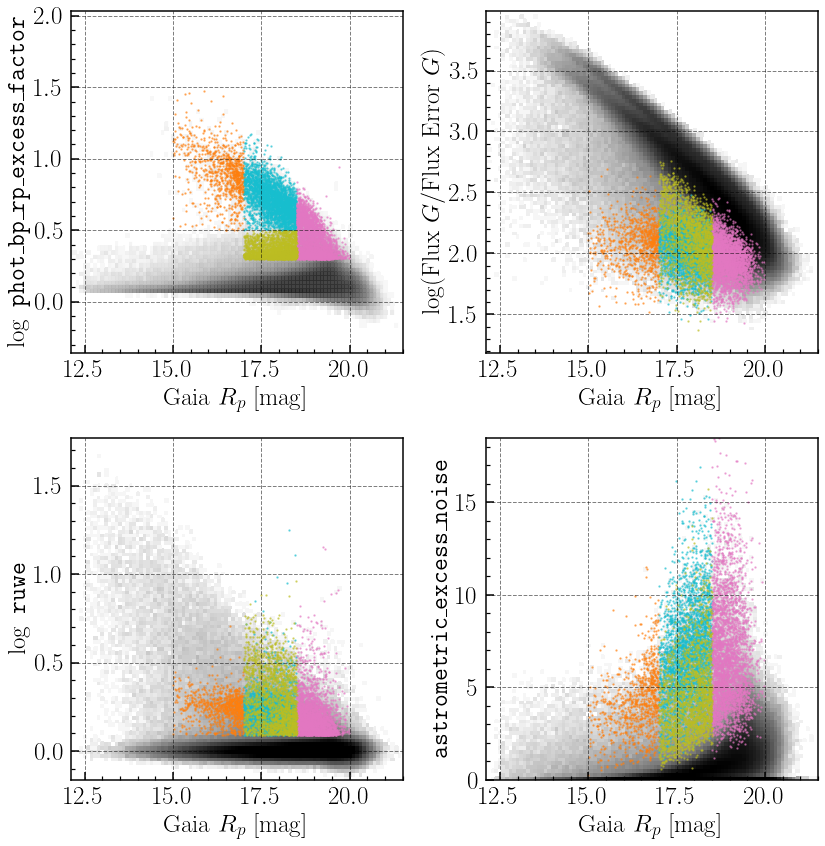

In [12]:
fig = plt.figure(figsize=(12, 12))
plt.subplots_adjust(bottom=0.1, right=0.99, top=0.99, hspace=0.25, wspace=0.25)

# Magnitude v.s. photometric excess factor
ax1 = fig.add_subplot(221)

_ = ax1.hist2d(hsc_use['phot_rp_mean_mag'], np.log10(hsc_use['phot_bp_rp_excess_factor']), bins=(100, 80), 
               vmin=1, norm=LogNorm(vmin=1, vmax=50000), alpha=0.9, cmap='Greys')

ax1.scatter(resolved_1['phot_rp_mean_mag'], np.log10(resolved_1['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:orange')
ax1.scatter(resolved_2['phot_rp_mean_mag'], np.log10(resolved_2['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:cyan')
ax1.scatter(resolved_3['phot_rp_mean_mag'], np.log10(resolved_3['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:pink')
ax1.scatter(resolved_4['phot_rp_mean_mag'], np.log10(resolved_4['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:olive')

ax1.grid(linestyle='--', c='k', alpha=0.5)

ax1.set_xlim(12.1, 21.5)

ax1.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax1.set_ylabel(r'$\log\ {\tt phot\_bp\_rp\_excess\_factor} $', fontsize=25)


# Magnitude v.s. Flux-over-error
ax2 = fig.add_subplot(222)

_ = ax2.hist2d(hsc_use['phot_rp_mean_mag'], np.log10(hsc_use['phot_g_mean_flux_over_error']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000), cmap='Greys')
ax2.scatter(resolved_1['phot_rp_mean_mag'], np.log10(resolved_1['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:orange')
ax2.scatter(resolved_2['phot_rp_mean_mag'], np.log10(resolved_2['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:cyan')
ax2.scatter(resolved_3['phot_rp_mean_mag'], np.log10(resolved_3['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:pink')
ax2.scatter(resolved_4['phot_rp_mean_mag'], np.log10(resolved_4['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:olive')

ax2.grid(linestyle='--', c='k', alpha=0.5)

ax2.set_xlim(12.1, 21.5)

ax2.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax2.set_ylabel(r'$\log({\rm Flux}\ G / {\rm Flux\ Error}\ G)$', fontsize=25)

# ruwe parameter
ax3 = fig.add_subplot(223)

_ = ax3.hist2d(hsc_use['phot_rp_mean_mag'], np.log10(hsc_use['ruwe']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000), cmap='Greys')
ax3.scatter(resolved_1['phot_rp_mean_mag'], np.log10(resolved_1['ruwe']), s=2, alpha=0.5, c='tab:orange')
ax3.scatter(resolved_2['phot_rp_mean_mag'], np.log10(resolved_2['ruwe']), s=2, alpha=0.5, c='tab:cyan')
ax3.scatter(resolved_3['phot_rp_mean_mag'], np.log10(resolved_3['ruwe']), s=2, alpha=0.5, c='tab:pink')
ax3.scatter(resolved_4['phot_rp_mean_mag'], np.log10(resolved_4['ruwe']), s=2, alpha=0.5, c='tab:olive')

ax3.grid(linestyle='--', c='k', alpha=0.5)

ax3.set_xlim(12.1, 21.5)

ax3.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax3.set_ylabel(r'$\log\ {\tt ruwe}$', fontsize=25)


ax4 = fig.add_subplot(224)

_ = ax4.hist2d(hsc_use['phot_rp_mean_mag'], hsc_use['astrometric_excess_noise'], bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000), cmap='Greys')

ax4.scatter(resolved_1['phot_rp_mean_mag'], resolved_1['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:orange')
ax4.scatter(resolved_2['phot_rp_mean_mag'], resolved_2['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:cyan')
ax4.scatter(resolved_3['phot_rp_mean_mag'], resolved_3['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:pink')
ax4.scatter(resolved_4['phot_rp_mean_mag'], resolved_4['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:olive')

ax4.grid(linestyle='--', c='k', alpha=0.5)

ax4.set_xlim(12.1, 21.5)

ax4.set_xlabel(r'${\rm Gaia}\ R_{p}\ [\rm mag]$', fontsize=25)
ax4.set_ylabel(r'${\tt astrometric\_excess\_noise}$', fontsize=25)

Text(0, 0.5, '${\\tt astrometric\\_excess\\_noise}$')

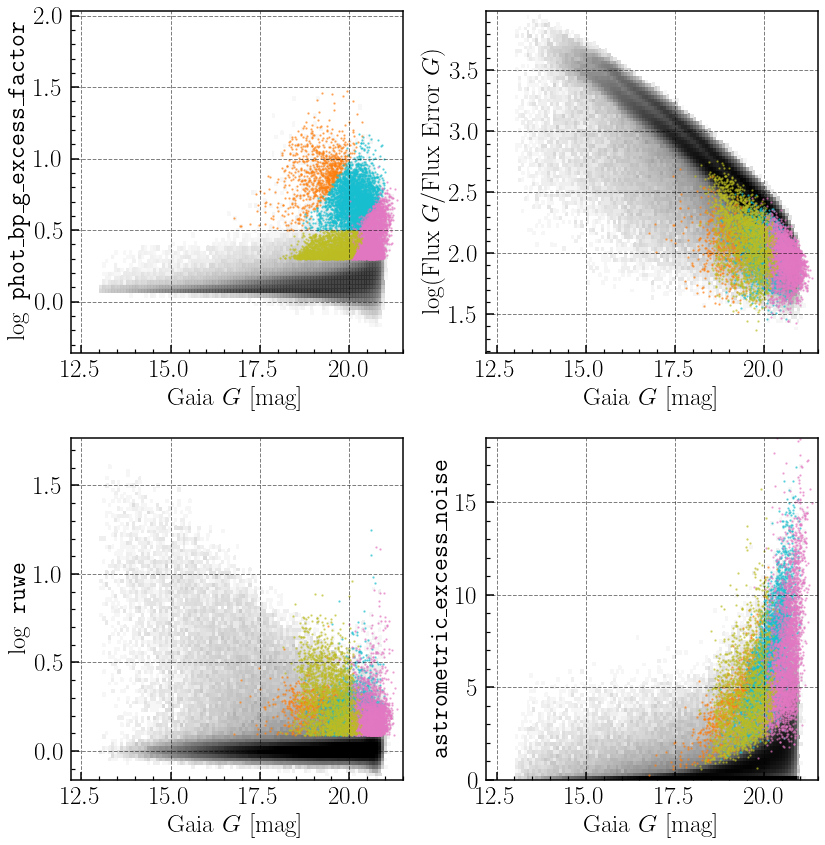

In [13]:
fig = plt.figure(figsize=(12, 12))
plt.subplots_adjust(bottom=0.1, right=0.99, top=0.99, hspace=0.25, wspace=0.25)

# Magnitude v.s. photometric excess factor
ax1 = fig.add_subplot(221)

_ = ax1.hist2d(hsc_use['phot_g_mean_mag'], np.log10(hsc_use['phot_bp_rp_excess_factor']), bins=(100, 80), 
               vmin=1, norm=LogNorm(vmin=1, vmax=50000), alpha=0.9, cmap='Greys')

ax1.scatter(resolved_1['phot_g_mean_mag'], np.log10(resolved_1['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:orange')
ax1.scatter(resolved_2['phot_g_mean_mag'], np.log10(resolved_2['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:cyan')
ax1.scatter(resolved_3['phot_g_mean_mag'], np.log10(resolved_3['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:pink')
ax1.scatter(resolved_4['phot_g_mean_mag'], np.log10(resolved_4['phot_bp_rp_excess_factor']), s=2, alpha=0.5, c='tab:olive')

ax1.grid(linestyle='--', c='k', alpha=0.5)

ax1.set_xlim(12.2, 21.5)

ax1.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax1.set_ylabel(r'$\log\ {\tt phot\_bp\_g\_excess\_factor} $', fontsize=25)


# Magnitude v.s. Flux-over-error
ax2 = fig.add_subplot(222)

_ = ax2.hist2d(hsc_use['phot_g_mean_mag'], np.log10(hsc_use['phot_g_mean_flux_over_error']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000), cmap='Greys')
ax2.scatter(resolved_1['phot_g_mean_mag'], np.log10(resolved_1['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:orange')
ax2.scatter(resolved_2['phot_g_mean_mag'], np.log10(resolved_2['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:cyan')
ax2.scatter(resolved_3['phot_g_mean_mag'], np.log10(resolved_3['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:pink')
ax2.scatter(resolved_4['phot_g_mean_mag'], np.log10(resolved_4['phot_g_mean_flux_over_error']), s=2, alpha=0.5, c='tab:olive')

ax2.grid(linestyle='--', c='k', alpha=0.5)

ax2.set_xlim(12.2, 21.5)

ax2.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax2.set_ylabel(r'$\log({\rm Flux}\ G / {\rm Flux\ Error}\ G)$', fontsize=25)

# ruwe parameter
ax3 = fig.add_subplot(223)

_ = ax3.hist2d(hsc_use['phot_g_mean_mag'], np.log10(hsc_use['ruwe']), bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000), cmap='Greys')
ax3.scatter(resolved_1['phot_g_mean_mag'], np.log10(resolved_1['ruwe']), s=2, alpha=0.5, c='tab:orange')
ax3.scatter(resolved_2['phot_g_mean_mag'], np.log10(resolved_2['ruwe']), s=2, alpha=0.5, c='tab:cyan')
ax3.scatter(resolved_3['phot_g_mean_mag'], np.log10(resolved_3['ruwe']), s=2, alpha=0.5, c='tab:pink')
ax3.scatter(resolved_4['phot_g_mean_mag'], np.log10(resolved_4['ruwe']), s=2, alpha=0.5, c='tab:olive')

ax3.grid(linestyle='--', c='k', alpha=0.5)

ax3.set_xlim(12.2, 21.5)

ax3.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax3.set_ylabel(r'$\log\ {\tt ruwe}$', fontsize=25)


ax4 = fig.add_subplot(224)

_ = ax4.hist2d(hsc_use['phot_g_mean_mag'], hsc_use['astrometric_excess_noise'], bins=(100, 90), 
               cmin=1, norm=LogNorm(vmin=1, vmax=5000), cmap='Greys')

ax4.scatter(resolved_1['phot_g_mean_mag'], resolved_1['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:orange')
ax4.scatter(resolved_2['phot_g_mean_mag'], resolved_2['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:cyan')
ax4.scatter(resolved_3['phot_g_mean_mag'], resolved_3['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:pink')
ax4.scatter(resolved_4['phot_g_mean_mag'], resolved_4['astrometric_excess_noise'], s=2, alpha=0.5, c='tab:olive')

ax4.grid(linestyle='--', c='k', alpha=0.5)

ax4.set_xlim(12.2, 21.5)

ax4.set_xlabel(r'${\rm Gaia}\ G\ [\rm mag]$', fontsize=25)
ax4.set_ylabel(r'${\tt astrometric\_excess\_noise}$', fontsize=25)

### Try different manifold learning methods

In [14]:
col_used = [
    'ra_error', 'dec_error', 'parallax', 'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 
    'ra_dec_corr', 'ra_parallax_corr', 'ra_pmra_corr', 'ra_pmdec_corr', 'dec_parallax_corr', 'dec_pmra_corr', 'dec_pmdec_corr', 'parallax_pmra_corr', 
    'parallax_pmdec_corr', 'pmra_pmdec_corr',
    'astrometric_gof_al', 'astrometric_chi2_al', 'astrometric_excess_noise', 'astrometric_excess_noise_sig',
    'astrometric_sigma5d_max', 'ipd_gof_harmonic_amplitude', 
    'ipd_gof_harmonic_phase', 'ruwe', 'scan_direction_strength_k1', 'scan_direction_strength_k2', 
    'scan_direction_strength_k3', 'scan_direction_strength_k4', 'scan_direction_mean_k1', 'scan_direction_mean_k2', 'scan_direction_mean_k3', 
    'scan_direction_mean_k4', 'phot_g_mean_flux_over_error', 'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag', 
    'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag', 'phot_bp_rp_excess_factor', 'bp_rp', 'bp_g', 'g_rp'
]

In [15]:
mask = (
    (hsc_use['phot_g_mean_mag'] >= 17.2) &
    np.isfinite(hsc_use['scan_direction_strength_k1']) & 
    np.isfinite(hsc_use['scan_direction_strength_k2']) &
    np.isfinite(hsc_use['scan_direction_strength_k3']) &
    np.isfinite(hsc_use['scan_direction_strength_k4']) &
    np.isfinite(hsc_use['scan_direction_mean_k1']) & 
    np.isfinite(hsc_use['scan_direction_mean_k2']) &
    np.isfinite(hsc_use['scan_direction_mean_k3']) &
    np.isfinite(hsc_use['scan_direction_mean_k4']) & 
    (hsc_use['parallax_over_error'] <= 30) & 
    (np.abs(hsc_use['pmra'] / hsc_use['pmra_error']) <= 100) &
    (np.abs(hsc_use['pmdec'] / hsc_use['pmdec_error']) <= 100)
)

print(mask.sum())

hsc_ml = hsc_use[mask]

1541496


(0.0, 30.0)

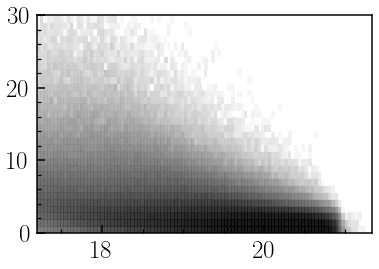

In [16]:
_ = plt.hist2d(hsc_ml['phot_g_mean_mag'], hsc_ml['parallax_over_error'], bins=(100, 50), 
               vmin=1, norm=LogNorm(vmin=1, vmax=5000), alpha=0.9, cmap='Greys')
plt.ylim(0, 30)

(-100.0, 100.0)

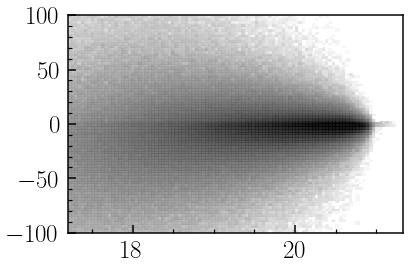

In [17]:
_ = plt.hist2d(hsc_ml['phot_g_mean_mag'], hsc_ml['pmra'] / hsc_ml['pmra_error'], bins=(100, 80), 
               vmin=1, norm=LogNorm(vmin=1, vmax=5000), alpha=0.9, cmap='Greys')

plt.ylim(-100, 100)

(-100.0, 100.0)

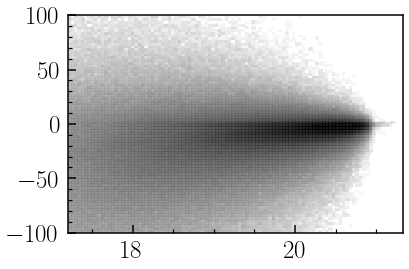

In [18]:
_ = plt.hist2d(hsc_ml['phot_g_mean_mag'], hsc_ml['pmdec'] / hsc_ml['pmdec_error'], bins=(100, 80), 
               vmin=1, norm=LogNorm(vmin=1, vmax=5000), alpha=0.9, cmap='Greys')

plt.ylim(-100, 100)

#### Make sure there is no weird values or infinite/NaN in the data

In [21]:
for col in col_used:
    print("{:40s} {:15.6f} {:15.6f} {:15.6f} {:15.6f}".format(
        col, np.min(hsc_ml[col]), np.max(hsc_ml[col]), np.nanmin(hsc_ml[col]), np.nanmax(hsc_ml[col])))

ra_error                                        0.037371        3.605064        0.037371        3.605064
dec_error                                       0.029655        3.472133        0.029655        3.472133
parallax                                      -35.077376       21.381947      -35.077376       21.381947
parallax_over_error                           -17.005423       29.997578      -17.005423       29.997578
pm                                              0.002349      247.134415        0.002349      247.134415
pmra                                         -246.849646      163.335044     -246.849646      163.335044
pmra_error                                      0.045071        3.389083        0.045071        3.389083
pmdec                                        -187.775945       74.196599     -187.775945       74.196599
pmdec_error                                     0.045906        3.349685        0.045906        3.349685
ra_dec_corr                                    -0.94786

#### Visualize the samples

In [20]:
for ii in np.random.choice(np.arange(len(resolved_1)), 200, replace=False):
    
    obj = resolved_1[ii]
    
    coord = SkyCoord(obj['ra'], obj['dec'], frame='icrs', unit='deg')

    # Use angular size and don't save the data
    cutout_rgb, cutout_wcs = task.hsc_tricolor(
        coord, cutout_size=(16.0 * u.arcsec), filters='gri', verbose=False, 
        save_rgb=True, save_img=False, use_saved=False, archive=s20a_w,
        prefix="group1_{:d}".format(obj['source_id']), 
        output_dir='/Users/song/Downloads/gaia_edr3_hsc/group1')

In [24]:
for ii in np.random.choice(np.arange(len(resolved_2)), 20, replace=False):
    
    obj = resolved_2[ii]
    
    coord = SkyCoord(obj['ra'], obj['dec'], frame='icrs', unit='deg')

    # Use angular size and don't save the data
    cutout_rgb, cutout_wcs = task.hsc_tricolor(
        coord, cutout_size=(16.0 * u.arcsec), filters='gri', verbose=False, 
        save_rgb=True, save_img=False, use_saved=False, archive=s20a_w,
        prefix="group2_{:d}".format(obj['source_id']), 
        output_dir='/Users/song/Downloads/gaia_edr3_hsc/group2')

In [25]:
for ii in np.random.choice(np.arange(len(resolved_3)), 200, replace=False):
    
    obj = resolved_3[ii]
    
    coord = SkyCoord(obj['ra'], obj['dec'], frame='icrs', unit='deg')

    # Use angular size and don't save the data
    cutout_rgb, cutout_wcs = task.hsc_tricolor(
        coord, cutout_size=(16.0 * u.arcsec), filters='gri', verbose=False, 
        save_rgb=True, save_img=False, use_saved=False, archive=s20a_w,
        prefix="group3_{:d}".format(obj['source_id']), 
        output_dir='/Users/song/Downloads/gaia_edr3_hsc/group3')

In [22]:
for ii in np.random.choice(np.arange(len(resolved_4)), 200, replace=False):
    
    obj = resolved_4[ii]
    
    coord = SkyCoord(obj['ra'], obj['dec'], frame='icrs', unit='deg')

    # Use angular size and don't save the data
    cutout_rgb, cutout_wcs = task.hsc_tricolor(
        coord, cutout_size=(16.0 * u.arcsec), filters='gri', verbose=False, 
        save_rgb=True, save_img=False, use_saved=False, archive=s20a_w,
        prefix="group4_{:d}".format(obj['source_id']), 
        output_dir='/Users/song/Downloads/gaia_edr3_hsc/group4')